# Third Assignment

##MSc course in Artificial Intelligence

Francesco Gnan

In [45]:
# !rm -r AI_USI_MA/
!git clone https://github.com/UmbertoJr/AI_USI_MA.git

fatal: destination path 'AI_USI_MA' already exists and is not an empty directory.


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from AI_USI_MA.solvers.local_search import twoOpt
from AI_USI_MA.solvers.constructive_algorithms import nn

---
We define the following class ACS in order to perform the so-called Ant Colony System search.

In [51]:
class ACS:
  m = 10
  beta = 2
  alpha = rho = 0.1
  cl = 20 # or 15
  iterations = 100
  q0 = 0.9

  @staticmethod
  def take_candidates(j, dist_mat):
    return list(np.argsort(dist_mat[j])[1:ACS.cl+1])

  def __init__(self, instance, optimal):
    self.opt = optimal
    self.n = instance.nPoints
    self.dist_mat = instance.dist_matrix
    _, self.L_nn = nn(instance.dist_matrix, starting_node=np.random.choice(self.n))
    self.tau0 = 1./(float(self.n) * self.L_nn)

    self.position = {i: None for i in range(ACS.m)}  # position collector for the Ants, TO BE UPDATED during the steps
    self.tour = {i: [] for i in range(ACS.m)}  # tour collector for the Ants

    #self.pheromone = {r: [self.tau0]*ACS.cl for r in range(self.n)}
    #self.candidate_list = {r: ACS.take_candidates(r, instance.dist_matrix) for r in range(self.n)}
    #self.eta = {r: [1/self.dist_mat[r, s] for s in ACS.take_candidates(r, instance.dist_matrix)] for r in range(self.n)}

    self.pheromone = {r: [self.tau0]*self.n for r in range(self.n)}
    epsilon = 1e-10 # to avoid division by zero in self.eta
    self.eta = {r: [1/(self.dist_mat[r, s] + epsilon) for s in range(self.n)] for r in range(self.n)}

    self.tour_length = {i: 0 for i in range(ACS.m)}
    self.visited_node = {i: [] for i in range(ACS.m)}
    self.best_tour = None
    self.best_tour_length = None

    self.final_tour = None
    self.final_tour_length = float( 'inf' )

    self.best_number_tours = None
    self.number_tours = 0

    self.save_all_results = []
    self.mean = []
    self.std = []

    self.iteration_gaps = []
    self.best_gap = 0

###############################################################################

  def positionate_ants(self):
    self.visited_node = {i: [False] * self.n for i in range(ACS.m)}
    self.tour = {i: [] for i in range(ACS.m)}

    for ant in range(ACS.m):

      current_node = np.random.randint(self.n)
      self.visited_node[ant][current_node] = True
      self.position[ant] = current_node
      self.tour[ant].append(current_node)
      self.tour_length[ant] = 0


      #print(f'ant {ant}')
      #print(self.position[ant])
      #print(self.tour[ant])
      #print(self.tour_length[ant])
      #print('----------------------------')


  def normalize(self, not_visited, ant):

      sum = 0.0
      r = self.position[ant]

      for u in not_visited:
          #print(self.eta[r][u])
          tau_ru = self.pheromone[r][u]
          eta_ru = self.eta[r][u]

          sum += tau_ru * eta_ru**ACS.beta

      return sum

  def create_one_tour(self, ant):

    while False in self.visited_node[ant]:
        not_visited = [j for j in range(len(self.visited_node[ant])) if not self.visited_node[ant][j]]

        prob_ru1 = []
        prob_ru2 = []

        next_city = 0

        r = self.position[ant]
        norm = self.normalize(not_visited, ant)

        for u in not_visited:
            tau_ru = self.pheromone[r][u]
            eta_ru = self.eta[r][u]

            prob_ru1.append(tau_ru * eta_ru**ACS.beta)
            prob_ru2.append(tau_ru * eta_ru**ACS.beta / norm)

        q = np.random.uniform(0, 1)

        if q <= ACS.q0:
            next_city_index = np.argmax(prob_ru1)
        else:
            next_city_index = np.random.choice(len(not_visited), p=prob_ru2)

        next_city = not_visited[next_city_index]

        self.tour[ant].append(next_city)
        self.position[ant] = next_city
        self.tour_length[ant] += self.dist_mat[r, next_city]
        self.visited_node[ant][next_city] = True


    #print('------------')
    #print('ant : ', ant)
    #print('tour ; ', self.tour[ant])
    #print('ant position :', self.position[ant])
    #print('tour length :', self.tour_length[ant])

  def go_back_to_initial_city(self):

    for ant in range(ACS.m):
        self.tour_length[ant] += self.dist_mat[self.position[ant], self.tour[ant][0]]
        self.position[ant] = self.tour[ant][0]

  def local_update(self, ant):

        for city in range(len(self.tour[ant])):

          r = self.tour[ant][city]

          if city == len(self.tour[ant]) - 1:
            s = self.tour[ant][0]
          else:
            s = self.tour[ant][city+1]

          tau_rs = self.pheromone[r][s]
          tau_rs = (1-ACS.rho) * tau_rs + ACS.rho * self.tau0
          self.pheromone[r][s] = tau_rs



  def get_best(self):

    best_ant = min(self.tour_length, key=self.tour_length.get)
    self.best_tour = self.tour[best_ant]
    self.best_tour_length = self.tour_length[best_ant]

    self.save_all_results.append(self.best_tour_length)

    if self.best_tour_length < self.final_tour_length:

      self.final_tour = self.best_tour
      self.final_tour_length = self.best_tour_length
      self.best_number_tours = self.number_tours

  def global_update(self):


    for city in range(len(self.best_tour)):

      r = self.best_tour[city]

      if city == len(self.best_tour) - 1:
        s = self.best_tour[0]
      else:
        s = self.best_tour[city+1]

      tau_rs = self.pheromone[r][s]
      tau_rs = (1-ACS.alpha) * tau_rs + ACS.alpha / self.best_tour_length
      self.pheromone[r][s] = tau_rs

  def get_statistics(self):

    self.mean.append( np.mean( self.save_all_results ) )
    self.std.append( np.std( self.save_all_results ) )
    gap = (self.final_tour_length - self.opt)/self.opt
    self.iteration_gaps.append( gap )

###############################################################################

  def search(self):

    for it in range(ACS.iterations):

      self.positionate_ants()

      for city in range(self.n - 1):
        for ant in range(ACS.m):

          self.create_one_tour(ant)
          self.local_update(ant)

      self.go_back_to_initial_city()

      self.number_tours += 1

      self.get_best()

      self.global_update()

      self.get_statistics()

    self.best_gap = (acs.final_tour_length - acs.opt)/acs.opt



We apply the Ant Colony System to four different instances of increasing size.
As far as each instance is concerned, we show:

*  the final tour length
*  the number of tours required to achieve the best result
*  the mean of all the tour lengths found
*  the corresponding standard deviation
*  the so-called gap, which gives us informations about how good is the final result compared to the optimal solution

In addition, we present two plots for each instance: one concerning the average length within every algorithm iteration; the other showing the gap as a function of the iterations.

name: myTSP_dim10
nPoints: 10
best_sol: 2732.0

Final length:  2732.0
Number of tours to achieve the best:  0
Mean:  2811.0
Std:  45.0
	 	 
======> gap:  0.0



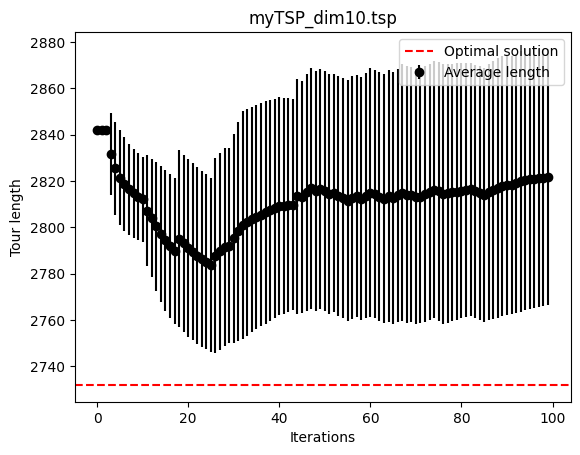

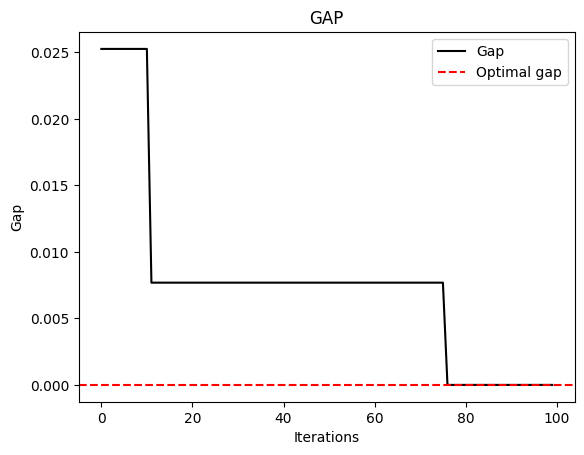

--------------------------------------------
name: d198
nPoints: 198
best_sol: 15780.0

Final length:  15970.0
Number of tours to achieve the best:  0
Mean:  19774.0
Std:  566.0
	 	 
======> gap:  0.012040557667934094



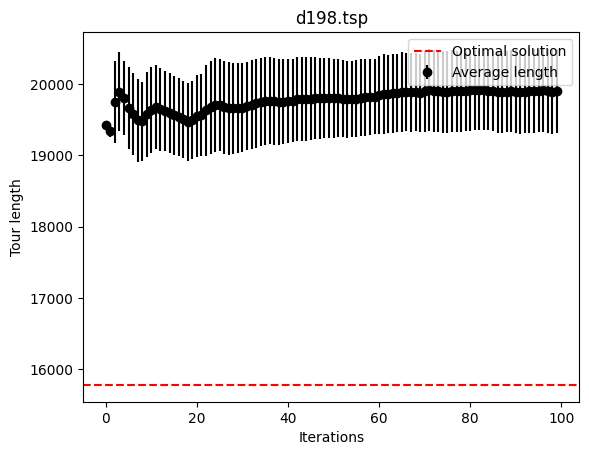

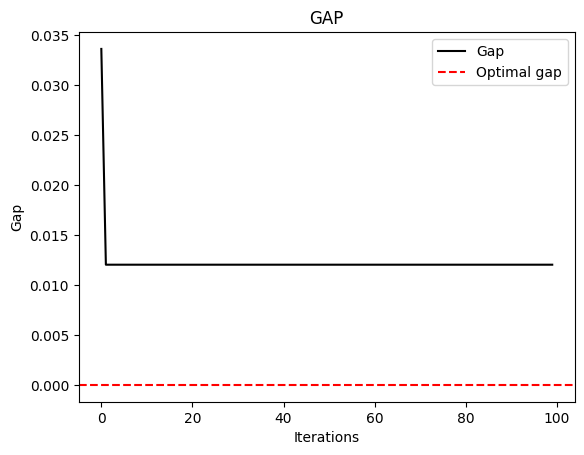

--------------------------------------------
name: ch130
nPoints: 130
best_sol: 6110.0

Final length:  6234.0
Number of tours to achieve the best:  0
Mean:  8016.0
Std:  257.0
	 	 
======> gap:  0.020294599018003272



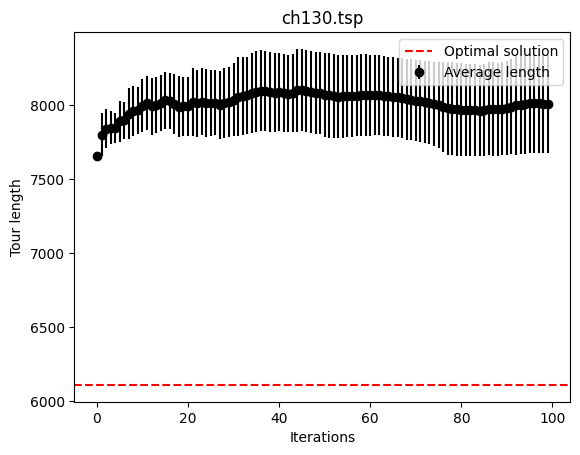

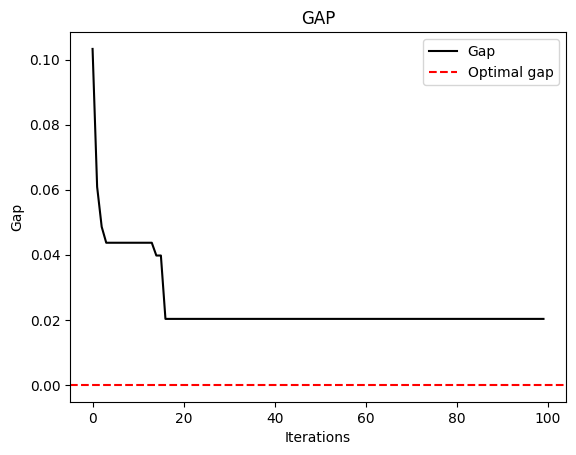

--------------------------------------------
name: eil76
nPoints: 76
best_sol: 538.0

Final length:  553.0
Number of tours to achieve the best:  0
Mean:  649.0
Std:  22.0
	 	 
======> gap:  0.027881040892193308



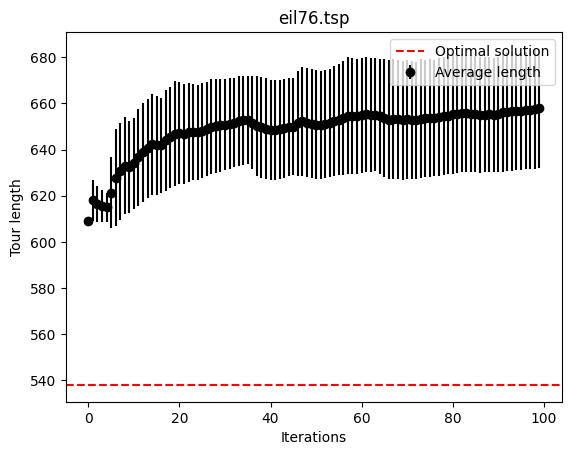

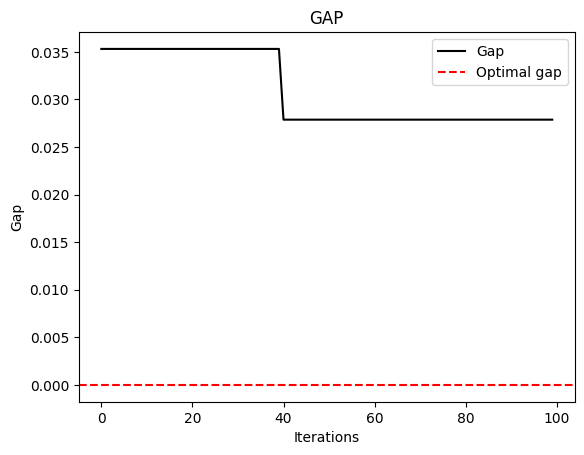

--------------------------------------------


In [66]:
#index = 2
for index in range(4):
  problem = ['myTSP_dim10.tsp', 'd198.tsp', 'ch130.tsp', 'eil76.tsp']

  ic = TSP_Instance_Creator("standard", problem[index])
  optimal = [2732.0, 15780.0, 6110.0, 538.0]


  ic.print_info()
  acs = ACS(ic, optimal[index])
  acs.search()
  #print(acs.final_tour)

  print('\nFinal length: ', acs.final_tour_length)
  print('Number of tours to achieve the best: ', acs.best_number_tours)
  print('Mean: ', round(np.mean(acs.mean),0))
  print('Std: ', round(np.mean(acs.std),0))
  print('\t \t \n======> gap: ',acs.best_gap)
  print()
  plt.title(problem[index])
  plt.errorbar([i for i in range(acs.iterations)], acs.mean, yerr=acs.std,fmt='o',color='k',label='Average length')
  plt.axhline(optimal[index], color='red', linestyle='--', label='Optimal solution')
  plt.xlabel('Iterations')
  plt.ylabel('Tour length')
  plt.legend()
  plt.show()

  plt.title('GAP')
  plt.plot([i for i in range(acs.iterations)], acs.iteration_gaps,color='k',label='Gap')
  plt.axhline(0, color='red', linestyle='--', label='Optimal gap')
  plt.xlabel('Iterations')
  plt.ylabel('Gap')
  plt.legend()
  plt.show()


  print('--------------------------------------------')


We observe that our code is able to find the optimal solution when it deals with the smaller instance, whereas it does not find it when it is applied to the other larger problems. However, we see that the code behave as we expect: its performance is decreasing as far as the problem size increases.

---
We now improve the ACS class, by applying the 2-opt for the best ant in each iteration. We expect it to find better results.

In [64]:
class ACS:
  m = 10
  beta = 2
  alpha = rho = 0.1
  cl = 20 # or 15
  iterations = 100
  q0 = 0.9

  @staticmethod
  def take_candidates(j, dist_mat):
    return list(np.argsort(dist_mat[j])[1:ACS.cl+1])

  def __init__(self, instance, optimal):

    self.opt = optimal
    self.n = instance.nPoints
    self.dist_mat = instance.dist_matrix
    _, self.L_nn = nn(instance.dist_matrix, starting_node=np.random.choice(self.n))
    self.tau0 = 1./(float(self.n) * self.L_nn)

    self.position = {i: None for i in range(ACS.m)}  # position collector for the Ants, TO BE UPDATED during the steps
    self.tour = {i: [] for i in range(ACS.m)}  # tour collector for the Ants

    #self.pheromone = {r: [self.tau0]*ACS.cl for r in range(self.n)}
    #self.candidate_list = {r: ACS.take_candidates(r, instance.dist_matrix) for r in range(self.n)}
    #self.eta = {r: [1/self.dist_mat[r, s] for s in ACS.take_candidates(r, instance.dist_matrix)] for r in range(self.n)}

    self.pheromone = {r: [self.tau0]*self.n for r in range(self.n)}
    epsilon = 1e-10 # to avoid division by zero in self.eta
    self.eta = {r: [1/(self.dist_mat[r, s] + epsilon) for s in range(self.n)] for r in range(self.n)}

    self.tour_length = {i: 0 for i in range(ACS.m)}
    self.visited_node = {i: [] for i in range(ACS.m)}
    self.best_tour = None
    self.best_tour_length = None

    self.final_tour = None
    self.final_tour_length = float( 'inf' )

    self.best_number_tours = None
    self.number_tours = 0

    self.save_all_results = []
    self.mean = []
    self.std = []

    self.iteration_gaps = []
    self.best_gap = 0

###############################################################################

  def positionate_ants(self):
    self.visited_node = {i: [False] * self.n for i in range(ACS.m)}
    self.tour = {i: [] for i in range(ACS.m)}

    for ant in range(ACS.m):

      current_node = np.random.randint(self.n)
      self.visited_node[ant][current_node] = True
      self.position[ant] = current_node
      self.tour[ant].append(current_node)
      self.tour_length[ant] = 0


      #print(f'ant {ant}')
      #print(self.position[ant])
      #print(self.tour[ant])
      #print(self.tour_length[ant])
      #print('----------------------------')


  def normalize(self, not_visited, ant):

      sum = 0.0
      r = self.position[ant]

      for u in not_visited:
          #print(self.eta[r][u])
          tau_ru = self.pheromone[r][u]
          eta_ru = self.eta[r][u]

          sum += tau_ru * eta_ru**ACS.beta

      return sum

  def create_one_tour(self, ant):

    while False in self.visited_node[ant]:
        not_visited = [j for j in range(len(self.visited_node[ant])) if not self.visited_node[ant][j]]

        prob_ru1 = []
        prob_ru2 = []

        next_city = 0

        r = self.position[ant]
        norm = self.normalize(not_visited, ant)

        for u in not_visited:
            tau_ru = self.pheromone[r][u]
            eta_ru = self.eta[r][u]

            prob_ru1.append(tau_ru * eta_ru**ACS.beta)
            prob_ru2.append(tau_ru * eta_ru**ACS.beta / norm)

        q = np.random.uniform(0, 1)

        if q <= ACS.q0:
            next_city_index = np.argmax(prob_ru1)
        else:
            next_city_index = np.random.choice(len(not_visited), p=prob_ru2)

        next_city = not_visited[next_city_index]

        self.tour[ant].append(next_city)
        self.position[ant] = next_city
        self.tour_length[ant] += self.dist_mat[r, next_city]
        self.visited_node[ant][next_city] = True


    #print('------------')
    #print('ant : ', ant)
    #print('tour ; ', self.tour[ant])
    #print('ant position :', self.position[ant])
    #print('tour length :', self.tour_length[ant])

  def go_back_to_initial_city(self):

    for ant in range(ACS.m):
        self.tour_length[ant] += self.dist_mat[self.position[ant], self.tour[ant][0]]
        self.position[ant] = self.tour[ant][0]

  def local_update(self, ant):

        for city in range(len(self.tour[ant])):

          r = self.tour[ant][city]

          if city == len(self.tour[ant]) - 1:
            s = self.tour[ant][0]
          else:
            s = self.tour[ant][city+1]

          tau_rs = self.pheromone[r][s]
          tau_rs = (1-ACS.rho) * tau_rs + ACS.rho * self.tau0
          self.pheromone[r][s] = tau_rs



  def get_best(self):

    best_ant = min(self.tour_length, key=self.tour_length.get)
    self.best_tour = self.tour[best_ant]
    self.best_tour_length = self.tour_length[best_ant]

    self.save_all_results.append(self.best_tour_length)

    if self.best_tour_length < self.final_tour_length:

      self.final_tour = self.best_tour
      self.final_tour_length = self.best_tour_length
      self.best_number_tours = self.number_tours

  def global_update(self):


    for city in range(len(self.best_tour)):

      r = self.best_tour[city]

      if city == len(self.best_tour) - 1:
        s = self.best_tour[0]
      else:
        s = self.best_tour[city+1]

      tau_rs = self.pheromone[r][s]
      tau_rs = (1-ACS.alpha) * tau_rs + ACS.alpha / self.best_tour_length
      self.pheromone[r][s] = tau_rs

  def get_statistics(self):

    self.mean.append( np.mean( self.save_all_results ) )
    self.std.append( np.std( self.save_all_results ) )
    gap = (self.final_tour_length - self.opt)/self.opt
    self.iteration_gaps.append( gap )


  def TWO_OPT(self):

    tour, lent_t = twoOpt(self.best_tour, self.best_tour_length, self.dist_mat)

    if lent_t < self.final_tour_length:

      self.final_tour = tour
      self.final_tour_length = lent_t

###############################################################################

  def search(self):

    for it in range(ACS.iterations):

      self.positionate_ants()

      for city in range(self.n - 1):
        for ant in range(ACS.m):

          self.create_one_tour(ant)
          self.local_update(ant)

      self.go_back_to_initial_city()

      self.get_best()

      self.TWO_OPT()

      self.global_update()

      self.get_statistics()

    self.best_gap = (acs.final_tour_length - acs.opt)/acs.opt



name: myTSP_dim10
nPoints: 10
best_sol: 2732.0

Final length:  2732.0
Number of tours to achieve the best:  0
Mean:  2822.0
Std:  25.0
	 	 
======> gap:  0.0



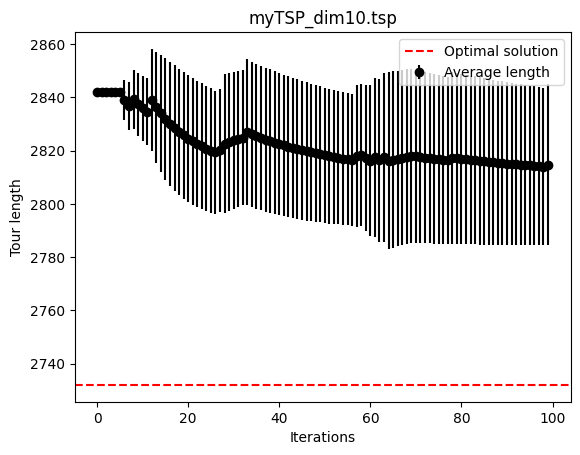

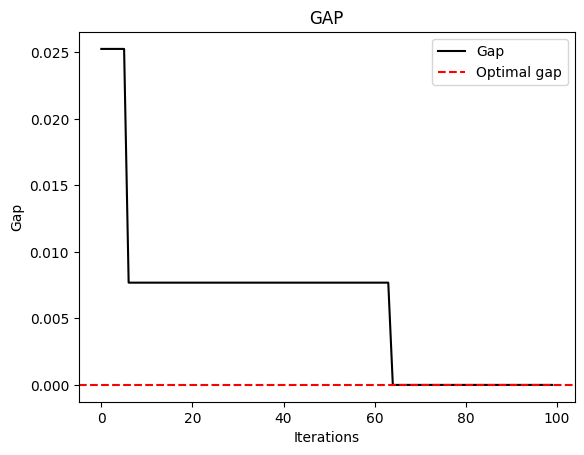

--------------------------------------------
name: d198
nPoints: 198
best_sol: 15780.0

Final length:  16013.0
Number of tours to achieve the best:  0
Mean:  19715.0
Std:  448.0
	 	 
======> gap:  0.014765525982256021



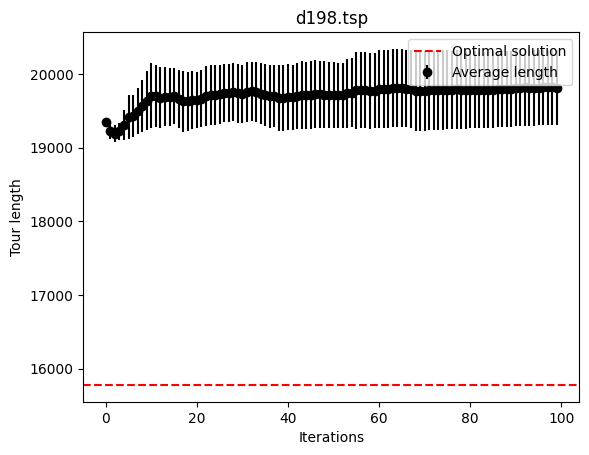

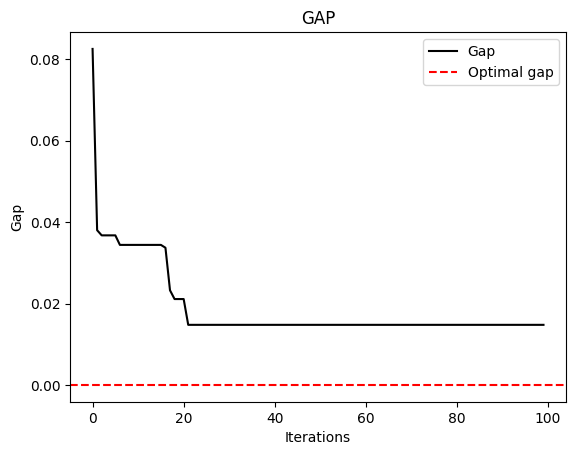

--------------------------------------------
name: ch130
nPoints: 130
best_sol: 6110.0

Final length:  6256.0
Number of tours to achieve the best:  0
Mean:  7928.0
Std:  254.0
	 	 
======> gap:  0.023895253682487724



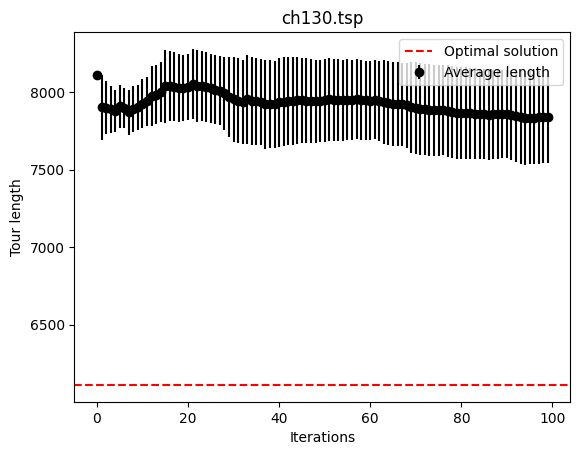

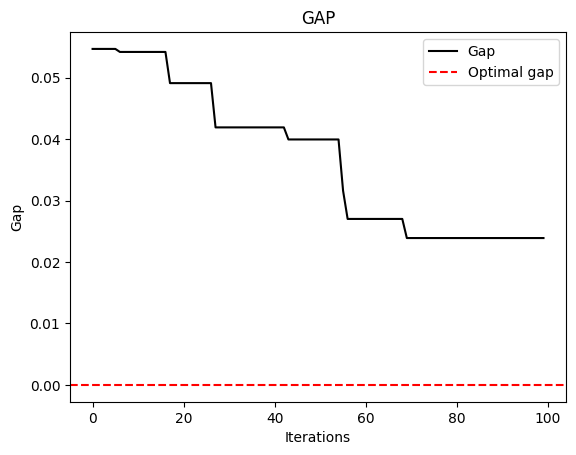

--------------------------------------------
name: eil76
nPoints: 76
best_sol: 538.0

Final length:  551.0
Number of tours to achieve the best:  0
Mean:  651.0
Std:  35.0
	 	 
======> gap:  0.024163568773234202



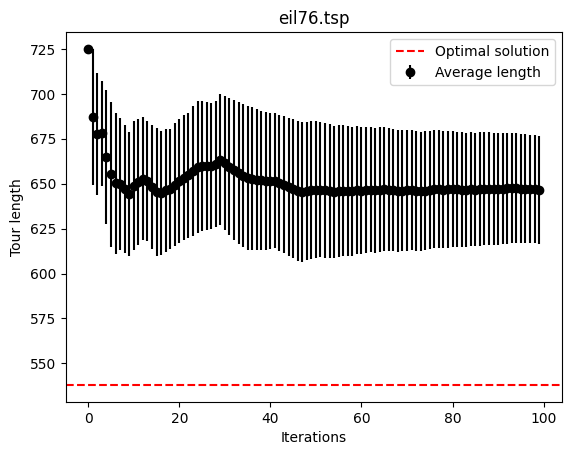

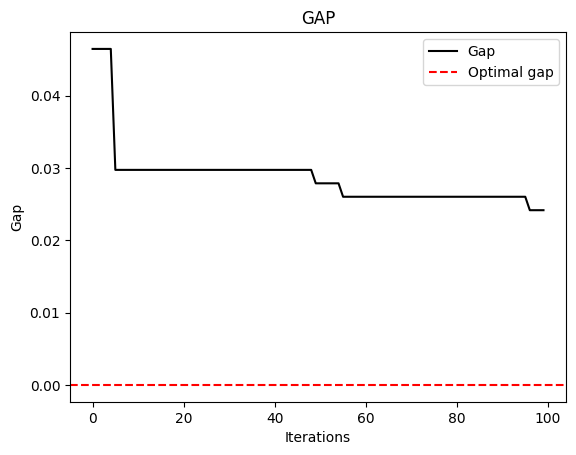

--------------------------------------------


In [65]:
#index = 2
for index in range(4):
  problem = ['myTSP_dim10.tsp', 'd198.tsp', 'ch130.tsp', 'eil76.tsp']

  ic = TSP_Instance_Creator("standard", problem[index])
  optimal = [2732.0, 15780.0, 6110.0, 538.0]


  ic.print_info()
  acs = ACS(ic, optimal[index])
  acs.search()
  #print(acs.final_tour)

  print('\nFinal length: ', acs.final_tour_length)
  print('Number of tours to achieve the best: ', acs.best_number_tours)
  print('Mean: ', round(np.mean(acs.mean),0))
  print('Std: ', round(np.mean(acs.std),0))
  print('\t \t \n======> gap: ',acs.best_gap)
  print()
  plt.title(problem[index])
  plt.errorbar([i for i in range(acs.iterations)], acs.mean, yerr=acs.std,fmt='o',color='k',label='Average length')
  plt.axhline(optimal[index], color='red', linestyle='--', label='Optimal solution')
  plt.xlabel('Iterations')
  plt.ylabel('Tour length')
  plt.legend()
  plt.show()

  plt.title('GAP')
  plt.plot([i for i in range(acs.iterations)], acs.iteration_gaps,color='k',label='Gap')
  plt.axhline(0, color='red', linestyle='--', label='Optimal gap')
  plt.xlabel('Iterations')
  plt.ylabel('Gap')
  plt.legend()
  plt.show()


  print('--------------------------------------------')


If we compare the final tour lengths found by the enhanced class, we observe that they are shorter, as we predicted. So we conclude that the application of the 2-opt is a valid improvement for the ACS.

---

Finally, we would like to extend more the same class, by inserting the use of the candidate list strategy. Unfortunately, we have not been able to add this improvement successfully. However, we report our implementation.

In [55]:
def read_candidate_list_from_LKH(file_name):
  """ This function reads the candidate list generated from the approaches available from the LKH implementation. :param file_name: the name of the file containing the candidate list is of the type *…cl
  inside each file there is a first row that contains the number of nodes in the TSP
  from the second line up to the end (which is given by -1 and EOF) the lines gives the following informations:
  a node number, the number of the dad of the node in the minimum spanning tree (0, if the node has no dad),
  the number of candidate edges emanating from the node,
  followed by the candidate edges. For each candidate edge its end node number and alpha-value are given.
  return: the candidate list saved as a dictionary were the key is the node number and the value is a list of the candidate edges
  """
  candidate_list = {}
  with open(file_name, 'r') as file:
    num_nodes = int(file.readline().strip())
    for line in file:
      line_data = list(map(int, line.strip().split()))
      if line_data[0] == -1:
        break
      node_number = line_data[0]
      num_candidate_edges = line_data[2]
      # Extract candidate edges information (end node number, alpha-value)|
      candidate_edges = [(int(line_data[i])-1, line_data[i + 1]) for i in range(3, 2 * num_candidate_edges + 3, 2)]
      candidate_list[int (node_number) - 1] = candidate_edges
  return candidate_list

In [56]:
class ACS:
  m = 10
  beta = 2
  alpha = rho = 0.1
  cl = 20 # or 15
  iterations = 10
  q0 = 0.5 #0.98, 1 - 13/self.n

  @staticmethod
  def take_candidates(j, dist_mat):
    return list(np.argsort(dist_mat[j])[1:ACS.cl+1])

  def __init__(self, instance):
    self.n = instance.nPoints
    self.dist_mat = instance.dist_matrix
    _, self.L_nn = nn(instance.dist_matrix, starting_node=np.random.choice(self.n))
    self.tau0 = 1. / (float(self.n) * self.L_nn)

    self.position = {i: None for i in range(ACS.m)}
    self.tour = {i: [] for i in range(ACS.m)}

    self.pheromone = {r: [self.tau0] * self.n for r in range(self.n)}  # Update to initialize the entire range
    self.candidate_list = {r: ACS.take_candidates(r, instance.dist_matrix) for r in range(self.n)}
    self.eta = {r: [1/self.dist_mat[r, s] for s in self.take_candidates(r, instance.dist_matrix)] for r in range(self.n)}

    self.tour_length = {i: 0 for i in range(ACS.m)}
    self.visited_node = {i: [] for i in range(ACS.m)}
    self.best_tour = None
    self.best_tour_length = None

    self.final_tour = None
    self.final_tour_length = float('inf')

###############################################################################

  def positionate_ants(self):
    self.visited_node = {i: [False] * self.n for i in range(ACS.m)}
    self.tour = {i: [] for i in range(ACS.m)}

    for ant in range(ACS.m):

      current_node = np.random.randint(self.n)
      self.visited_node[ant][current_node] = True
      self.position[ant] = current_node
      self.tour[ant].append(current_node)
      self.tour_length[ant] = 0


      #print(f'ant {ant}')
      #print(self.position[ant])
      #print(self.tour[ant])
      #print(self.tour_length[ant])
      #print('----------------------------')


  def normalize(self, not_visited, ant):

      sum = 0.0
      r = self.position[ant]

      for u in not_visited:
          #print(self.eta[r][u])
          tau_ru = self.pheromone[r][u]
          eta_ru = self.eta[r][u]

          sum += tau_ru * eta_ru**ACS.beta

      return sum

  def create_one_tour(self, ant):

    while False in self.visited_node[ant]:
        r = self.position[ant]

        not_visited_candidates = [j for j in self.candidate_list[r] if not self.visited_node[ant][j]]

        if not not_visited_candidates:
            not_visited_candidates = [j for j in range(self.n) if not self.visited_node[ant][j]]

        prob_ru1 = []
        prob_ru2 = []

        next_city = 0
        norm = self.normalize(not_visited_candidates, ant)

        for u in not_visited_candidates:
            # Ensure that the index is within the valid range
            tau_ru = self.pheromone[r][u] if u < len(self.pheromone[r]) else 0
            eta_ru = self.eta[r][u] if u < len(self.eta[r]) else 0

            prob_ru1.append(tau_ru * eta_ru**ACS.beta)
            prob_ru2.append(tau_ru * eta_ru**ACS.beta / norm)

        q = np.random.uniform(0, 1)
        if q <= ACS.q0:
            next_city_index = np.argmax(prob_ru1)
        else:
            next_city_index = np.random.choice(len(not_visited_candidates), p=prob_ru2)

        next_city = not_visited_candidates[next_city_index]

        self.tour[ant].append(next_city)
        self.position[ant] = next_city
        self.tour_length[ant] += self.dist_mat[r, next_city]
        self.visited_node[ant][next_city] = True


    #print('------------')
    #print('ant : ', ant)
    #print('tour ; ', self.tour[ant])
    #print('ant position :', self.position[ant])
    #print('tour length :', self.tour_length[ant])

  def go_back_to_initial_city(self):

    for ant in range(ACS.m):
        self.tour_length[ant] += self.dist_mat[self.position[ant], self.tour[ant][0]]
        self.position[ant] = self.tour[ant][0]

  def local_update(self, ant):

        for city in range(len(self.tour[ant])):

          r = self.tour[ant][city]

          if city == len(self.tour[ant]) - 1:
            s = self.tour[ant][0]
          else:
            s = self.tour[ant][city+1]

          tau_rs = self.pheromone[r][s]
          tau_rs = (1-ACS.rho) * tau_rs + ACS.rho * self.tau0
          self.pheromone[r][s] = tau_rs



  def get_best(self):

    best_ant = min(self.tour_length, key=self.tour_length.get)
    self.best_tour = self.tour[best_ant]
    self.best_tour_length = self.tour_length[best_ant]

    if self.best_tour_length < self.final_tour_length:

      self.final_tour = self.best_tour
      self.final_tour_length = self.best_tour_length

  def global_update(self):


    for city in range(len(self.best_tour)):

      r = self.best_tour[city]

      if city == len(self.best_tour) - 1:
        s = self.best_tour[0]
      else:
        s = self.best_tour[city+1]

      tau_rs = self.pheromone[r][s]
      tau_rs = (1-ACS.alpha) * tau_rs + ACS.alpha / self.best_tour_length
      self.pheromone[r][s] = tau_rs


  def TWO_OPT(self):

    tour, lent_t = twoOpt(self.best_tour, self.best_tour_length, self.dist_mat)

    if lent_t < self.final_tour_length:

      self.final_tour = tour
      self.final_tour_length = lent_t

###############################################################################

  def search(self):

    for it in range(ACS.iterations):

      self.positionate_ants()

      for city in range(self.n - 1):
        for ant in range(ACS.m):

          self.create_one_tour(ant)
          self.local_update(ant)

      self.go_back_to_initial_city()

      self.get_best()

      self.TWO_OPT()

      self.global_update()

